In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
import illustris_python as il

In [3]:
from astropy import units as u

In [4]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

/tmp/ipykernel_37788/82325636.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [5]:
%load_ext autoreload
%autoreload 2

In [90]:
def plot_histogram(df, prop, labels=None, bins=100, log=True):
    scale = 0.5
    labelsize = 55*scale
    x_tick_major_size = 16*scale
    x_tick_major_width = 4*scale
    x_tick_minor_size = 8*scale
    x_tick_minor_width = 3*scale
    fig_width = 25*scale
    fig_height = 15*scale
    axes_width = 3*scale
    tick_labelsize = 35*scale
    
    plt.rcParams["figure.figsize"] = (fig_width, fig_height)
    plt.rc('axes', linewidth=axes_width)
    plt.rc('xtick', labelsize=tick_labelsize) 
    plt.rc('ytick', labelsize=tick_labelsize) 
    
    if labels == None:
        if prop == 'Column_dens_r':
            x_label = r'$\log(\rho)[\log(\mathrm{gcm}^{-3})]$'
            y_label = r'p.d.f.($\log(\rho)$)'
            labels = {'x':x_label, 'y':y_label}
        elif prop == 'Column_height_r':
            x_label = '$\log(h)[\log(\mathrm{cm})]$'
            y_label = r'p.d.f.($\log(h)$)'
            labels = {'x':x_label, 'y':y_label}
        
    ax = plt.axes()
    ax.tick_params(length=x_tick_major_size, width=x_tick_major_width)
    ax.tick_params(length=x_tick_minor_size, width=x_tick_minor_width, which='minor')
    if log:
        input_val = np.log10(df[prop])
    else:
        input_val = df[prop]
    ax.hist(input_val, bins=100, density=True)
    ax.set_xlabel(labels['x'], size=labelsize)
    ax.set_ylabel(labels['y'], size=labelsize)
    plt.show();
    return

In [85]:
def plot_fesc_dependence(df, prop, labels=None, log=False, mode=None):
    scale = 0.5
    labelsize = 55*scale
    x_tick_major_size = 16*scale
    x_tick_major_width = 4*scale
    x_tick_minor_size = 8*scale
    x_tick_minor_width = 3*scale
    fig_width = 25*scale
    fig_height = 15*scale
    axes_width = 3*scale
    tick_labelsize = 35*scale
    scattersize = 30*scale
    legendsize = 50*scale
    
    plt.rcParams["figure.figsize"] = (fig_width, fig_height)
    plt.rc('axes', linewidth=axes_width)
    plt.rc('xtick', labelsize=tick_labelsize) 
    plt.rc('ytick', labelsize=tick_labelsize) 
        
    ax = plt.axes()
    ax.tick_params(length=x_tick_major_size, width=x_tick_major_width)
    ax.tick_params(length=x_tick_minor_size, width=x_tick_minor_width, which='minor')


    modes = ['r', '2r', 'sf_r', 'sf_2r']
    plt_labels = ['$\Sigma_\mathrm{SFR}(r_\mathrm{SHMR})$',
                  '$\Sigma_\mathrm{SFR}(2r_\mathrm{SHMR})$',
                  'SFR$(r_\mathrm{SHMR})$',
                  'SFR$(2r_\mathrm{SHMR})$']
    
    if log:
        input_val = np.log10(df[prop])
    else:
        input_val = df[prop]

    if mode == None:
        for mode, label in zip(modes, plt_labels):
            ax.scatter(input_val, df['f_esc_'+mode], s=scattersize, label=label)
    else:
        ax.scatter(input_val, df['f_esc_'+mode], s=scattersize)
    
    if labels != None:
        ax.set_xlabel(labels['x'], size=labelsize)
        ax.set_ylabel(labels['y'], size=labelsize)
    plt.legend(fontsize=legendsize)
    plt.ylim(0, 1.05)
    plt.show()
    return

In [ ]:
plt.scatter(df['f_g_r'], np.log10(df['Sigma_SFR_r']/conv**2), s=10, c=df['f_esc_r'])
plt.xlabel('$f_{gas,r}$', size=50)
plt.ylabel('$\log (\Sigma_\mathrm{SFR})[M_\odot\mathrm{kpc}^{-2}\mathrm{yr}^{-1}]$', size=50)
cbar = plt.colorbar()
cbar.set_label('$f_\mathrm{esc}$', size=50)

In [28]:
df_path = f'/ptmp/mpa/ivkos/semianalytic_fesc/sn013/2_df.pickle'
df = pd.read_pickle(df_path)

In [39]:
test_df = df.iloc[1000:2000]
df_test_path = f'/ptmp/mpa/ivkos/semianalytic_fesc/sn013/2_test_df.pickle'
test_df.to_pickle(df_test_path)

In [40]:
test_df = pd.read_pickle(df_test_path)

In [70]:
full_path = f'/ptmp/mpa/ivkos/semianalytic_fesc/sn013/full_df.pickle'
df = pd.read_pickle(full_path)

In [72]:
u.Msun

Unit("solMass")

In [77]:
g_to_msun = (1*u.g).to(u.Msun).value
df['M_gas_sun'] = df['M_gas_r']*g_to_msun
df['M_star_sun'] = df['M_star_r']*g_to_msun

In [84]:
df[df['f_esc_sf_r']>0.9]['f_esc_sf_r'].describe()

count    338.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: f_esc_sf_r, dtype: float64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


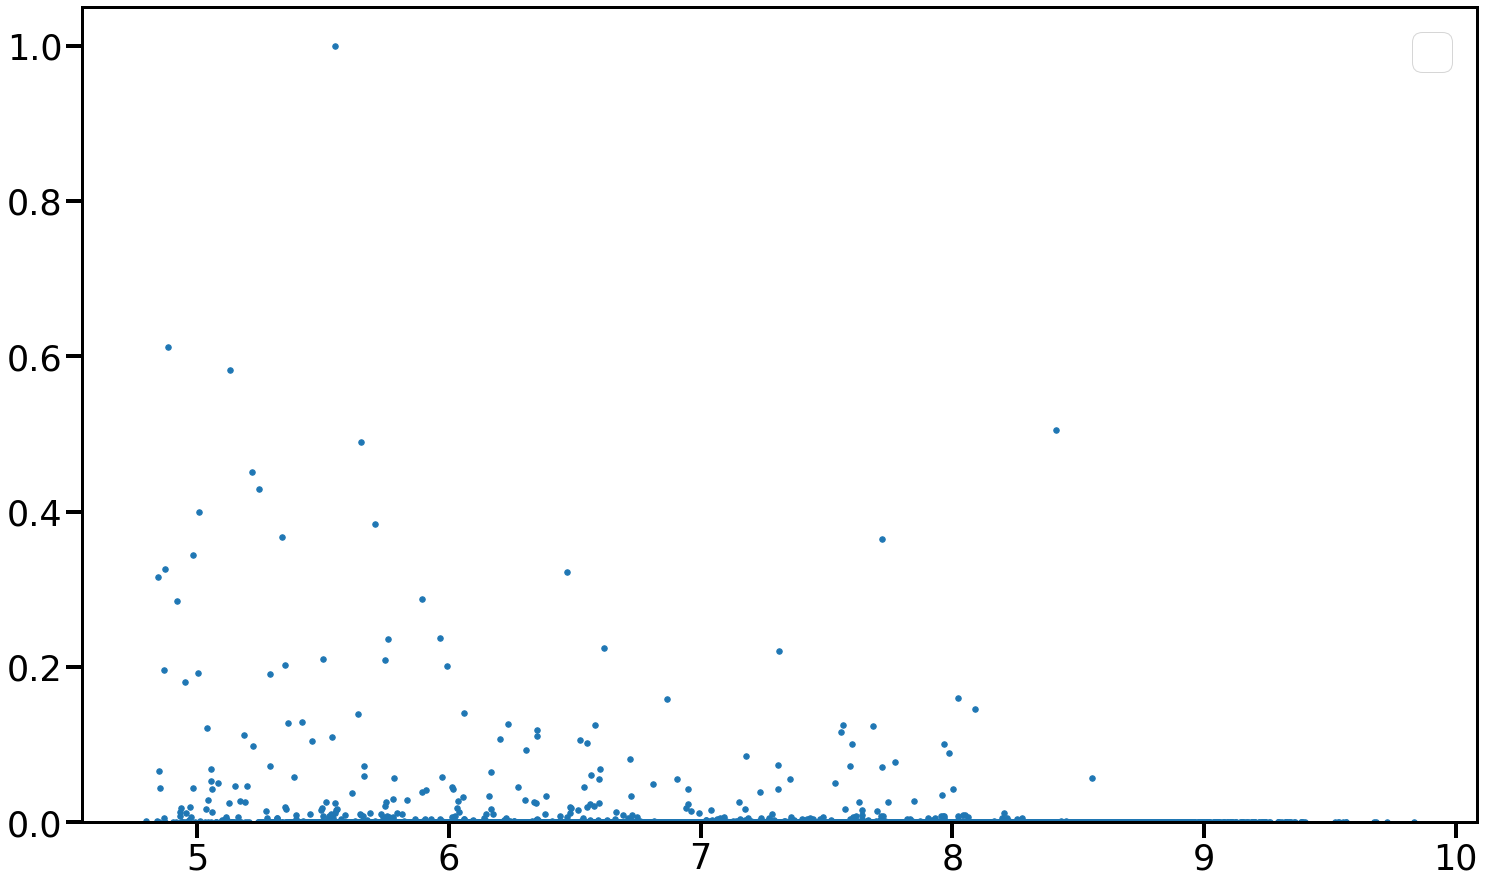

In [89]:
plot_fesc_dependence(df, 'M_gas_sun', labels=None, log=True, mode='sf_r')

In [59]:
test_df.columns

Index(['Z_2r', 'Z_r', 'r', 'SFR_r', 'SFR_2r', 'Halo_pos_x', 'Halo_pos_y',
       'Halo_pos_z', 'M_gas_2r', 'V_2r', 'M_star_2r', 'M_gas_r', 'V_r',
       'M_star_r', 'Redshift', 'Bol_lum_sf_2r', 'Ion_em_sf_2r', 'M_gas_sf_2r',
       'SFR_sf_2r', 'M_star_sf_2r', 'V_sf_2r', 'Z_sf_2r', 'Bol_lum_sf_r',
       'Ion_em_sf_r', 'M_gas_sf_r', 'SFR_sf_r', 'M_star_sf_r', 'V_sf_r',
       'Z_sf_r', 'Tot_Bol_lum_2r', 'Tot_Ion_em_2r', 'Tot_Bol_lum_r',
       'Tot_Ion_em_r'],
      dtype='object')